In [39]:
## Imports:import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.metrics import pairwise_distancesfrom scipy.optimize import minimizeimport random

# 1. Data Preparation:
1.1 Load the dataset and perform necessary preprocessing steps for KNN. Specify and apply these steps as needed.

aside from loading the data

we're going to start by perform a few preprocessing tasks:

    1. dealing with duplicates

    2. dealing with missing values

    3. encoding categorical variables.
    
    4. feature scaling

In [6]:
data = pd.read_csv('P3.csv', index_col=0)data.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,label
0,0.140023,0.265418,-0.535880,0.808262,-0.998551,1.147053,0.979441,0.722351,0.559936,0.399382,1.098400,0.036805,1.302542,-0.239813,0.625914,0.0
1,1.176099,1.690023,-0.737042,1.207350,-1.249740,-0.921881,0.065195,-0.581772,0.645254,-0.089174,-1.571598,0.633757,0.636572,1.233946,-0.300362,1.0
2,1.322751,0.635943,0.012525,0.027479,0.083267,0.447982,1.158902,1.177922,0.887521,0.018378,-0.395321,0.451929,0.744254,-0.492224,-0.316476,1.0
3,0.907289,-0.475599,-1.270970,1.837189,-2.471438,1.270536,-0.536260,-0.852590,0.778421,0.362119,-1.111151,0.153531,-0.342588,-0.147104,-0.585484,0.0
4,0.809604,1.039083,0.869025,-1.204626,1.756469,0.318814,-2.582921,-1.493409,-1.221354,0.435062,-0.068407,0.942154,0.329038,0.375319,-0.843292,1.0


lest check for duplicates 

In [7]:
num_duplicates = data.duplicated().sum()num_duplicates

0

so no duplicates

lets check for the missing values

In [8]:
data.isnull().sum()

f1       0
f2       0
f3       0
f4       0
f5       0
f6       0
f7       0
f8       0
f9       0
f10      0
f11      0
f12      0
f13      0
f14      0
f15      0
label    0
dtype: int64

so no null values as well

so lest check the format of each feature, to see if we have any categorical features to encode

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      300 non-null    float64
 1   f2      300 non-null    float64
 2   f3      300 non-null    float64
 3   f4      300 non-null    float64
 4   f5      300 non-null    float64
 5   f6      300 non-null    float64
 6   f7      300 non-null    float64
 7   f8      300 non-null    float64
 8   f9      300 non-null    float64
 9   f10     300 non-null    float64
 10  f11     300 non-null    float64
 11  f12     300 non-null    float64
 12  f13     300 non-null    float64
 13  f14     300 non-null    float64
 14  f15     300 non-null    float64
 15  label   300 non-null    float64
dtypes: float64(16)
memory usage: 39.8 KB


looks like all the values are 'float' so nothing to encode

ok, so lets do a bit of 'feature scaling'

so for KNN, there are 2 main methods, 'z-score' and 'min-max', but which one is better ? 

a bit of research shows Min-Max Scaling is often preferred when you want to maintain the relationships between values. However, it's sensitive to outliers since they can significantly affect the range.

Standardization is typically more robust to outliers and is often the go-to method when the features have different units or scales.

so looks like we have to see if we have a lot of outliers or not, then we can find the best feature scaler.

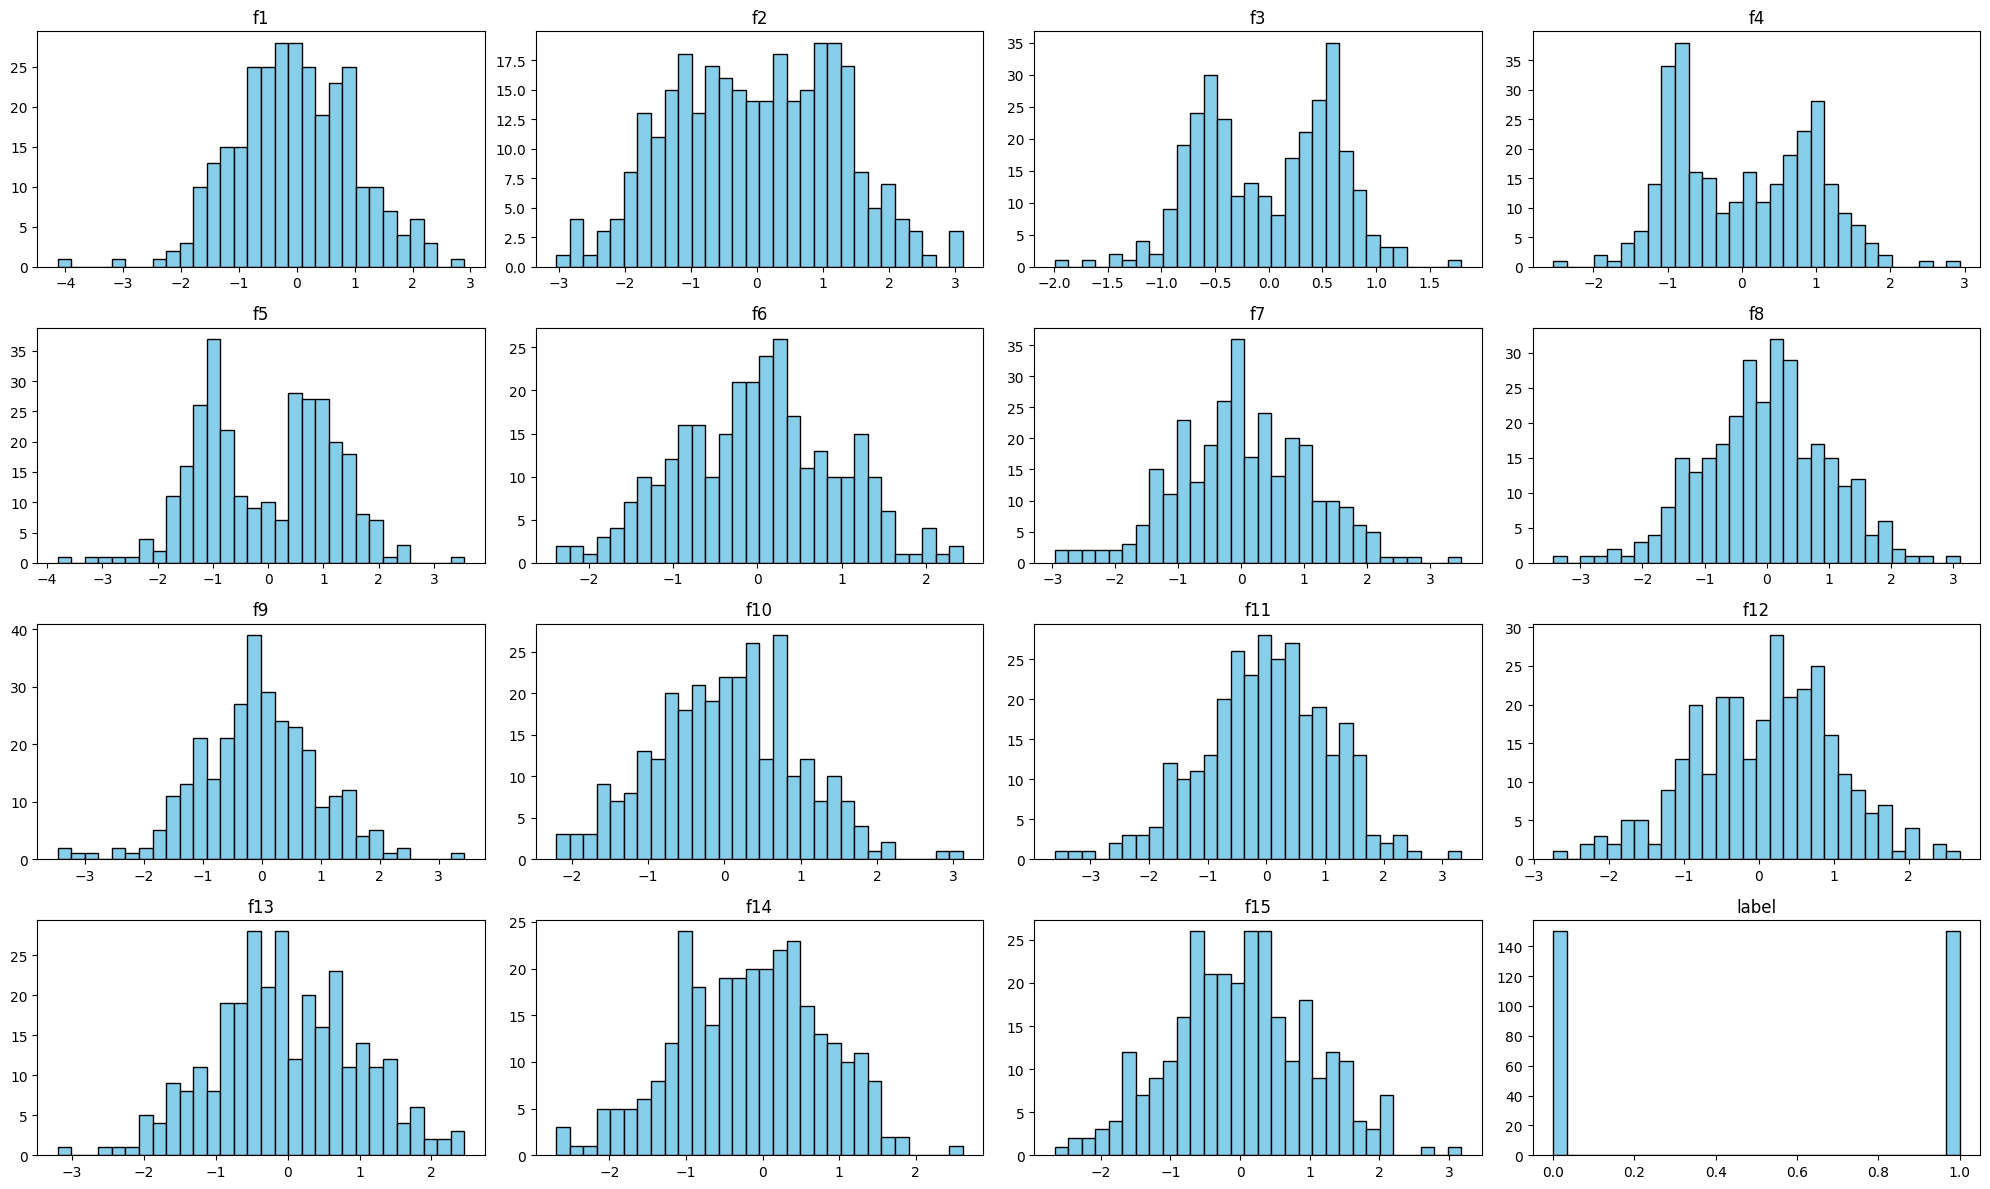

In [10]:
fig, axs = plt.subplots(4, 4, figsize=(20, 12))axs = axs.flatten()for i, column in enumerate(data.columns):    axs[i].hist(data[column], bins=30, color='skyblue', edgecolor='black')    axs[i].set_title(column)# Removeunused subplotsfor j in range(i + 1, len(axs)):    fig.delaxes(axs[j])plt.tight_layout()plt.show()

except the 'lable' which is binary and understandable, and 'f3', 'f4', and 'f5', the rest of the features look normaly distributed


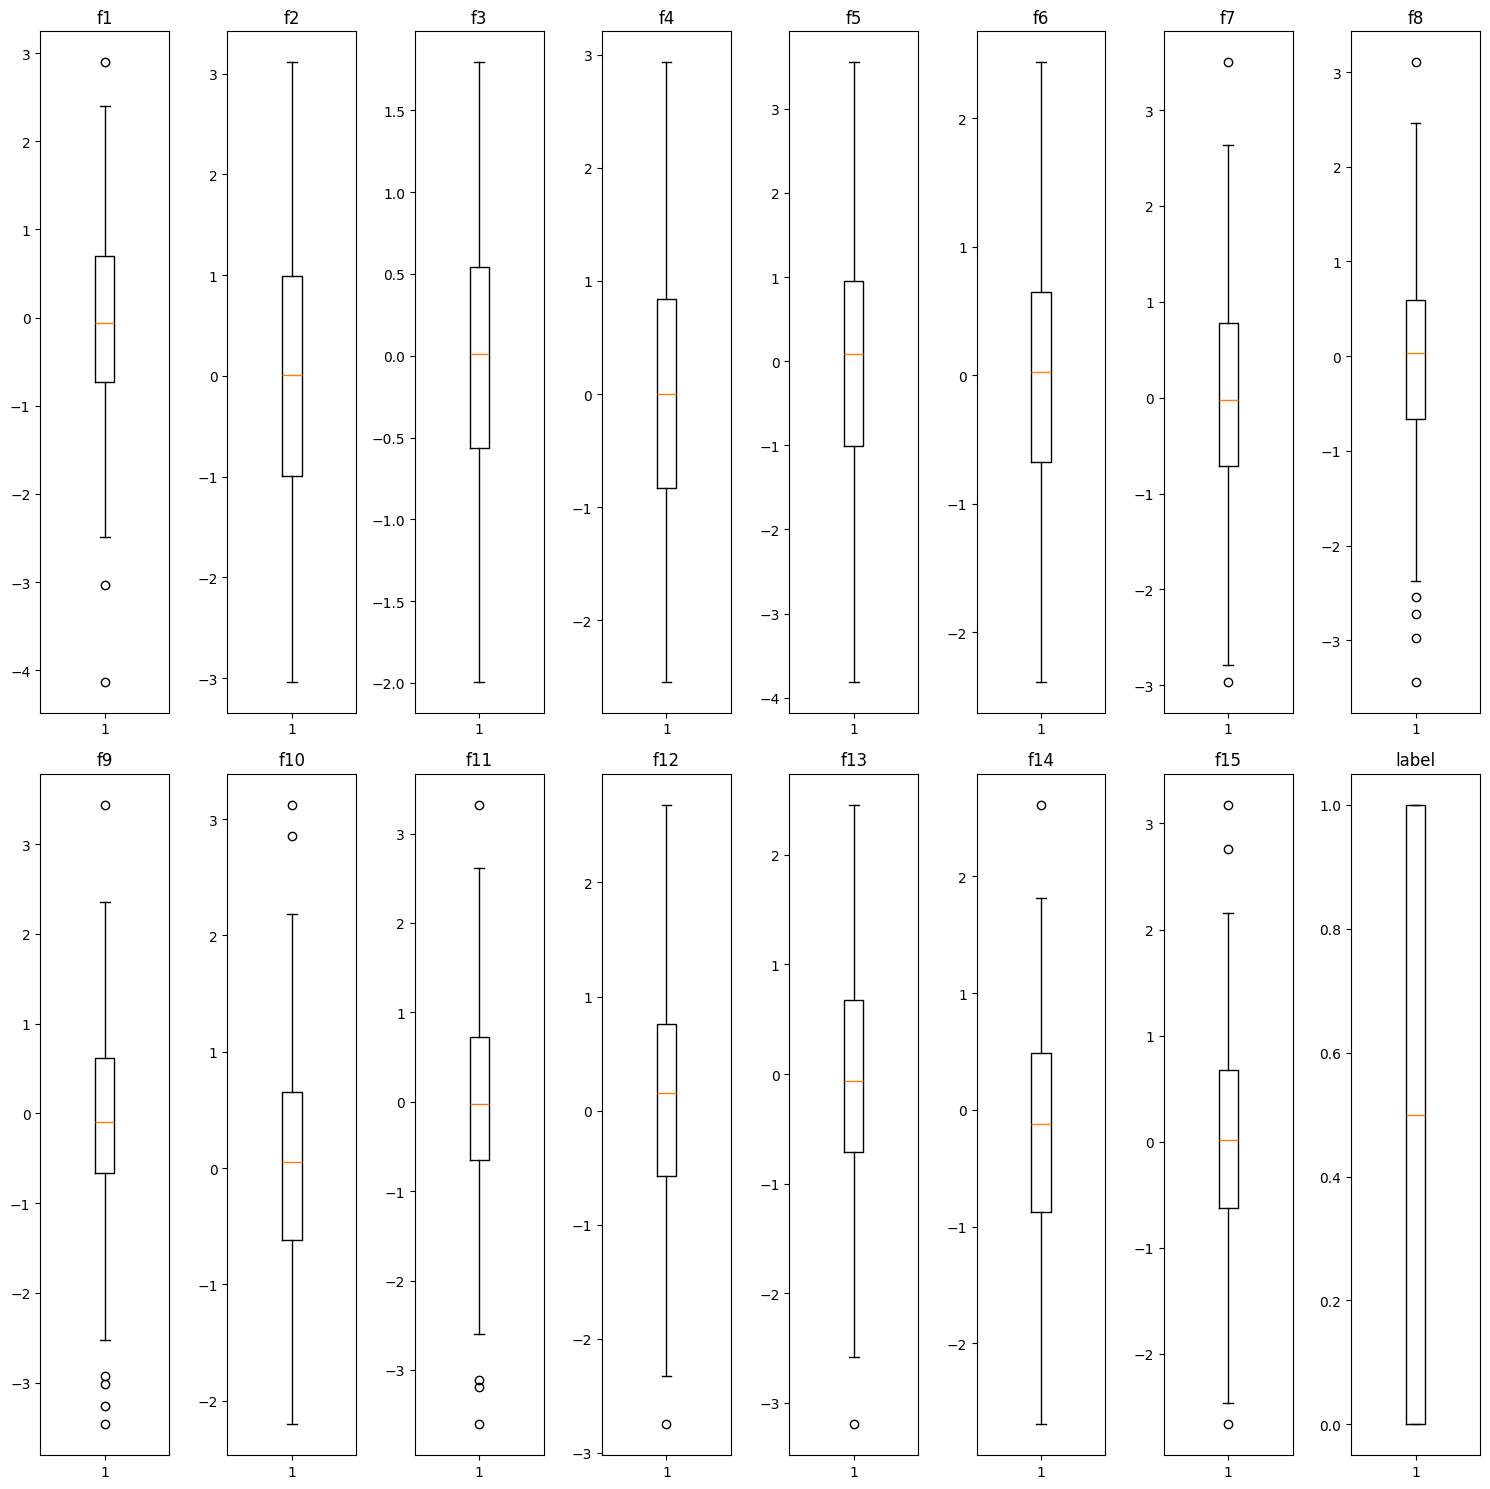

In [11]:
fig, axs = plt.subplots(2, 8, figsize=(15, 15))axs = axs.flatten()# distribution of each featurefor i, column in enumerate(data.columns):    axs[i].boxplot(data[column])    axs[i].set_title(column)# Remove unused subplotsfor j in range(i + 1, len(axs)):    fig.delaxes(axs[j])plt.tight_layout()plt.show()

seems like we have a fair amount of outliers, looking back at what we said about 'z-score' and 'min-max', we now can choose the 'z-score'

In [12]:
z_scaled_data = data.drop('label', axis=1)